# Decoding Analysis

Applies PCA to activity data to obtain decoding manifolds (averaged over time) and decoding trajectories (dynamics over time).

In [271]:
import os
import pickle
import logging

import numpy as np
import matplotlib.pyplot as plt

from tueplots import bundles
from tueplots.constants.color import rgb
from sklearn.decomposition import PCA
import plotly.graph_objects as go

from utils import *

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

plt.rcParams.update(bundles.neurips2021(usetex=False))

results_dict = {}

#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs0_maxFr_maxNr_seed1"; low_sf = True 
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks0_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs1_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks1_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs2_maxFr_maxNr_seed1"; low_sf = True
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1"; low_sf = True
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_recurrentout_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_position_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_seed2"; low_sf = False

PREFIX = "Retina"; low_sf = True
#PREFIX = "V1"; low_sf = True

## Load activity data

In [272]:
basedir = '../data/sampled_data'

if PREFIX == "V1":
    tensor4d = np.load("../data/V1_tensor_traces.npy")
elif PREFIX == "Retina":
    tensor4d = np.load("../data/retina_tensor_traces.npy")
else:
    tensor4d = np.load(f'{basedir}/tensor4d_{PREFIX}.npy')

if low_sf:
    tensor4d = tensor4d[:, :6]
else:
    tensor4d = tensor4d[:, np.array([0, 6, 7, 8, 9, 10])]

print(f"(Neurons, Stimuli, Orientation, Trial len): {tensor4d.shape}")

(Neurons, Stimuli, Orientation, Trial len): (1146, 6, 8, 135)


### Filtering

FILTERING MODE: Global Average (All Stimuli)


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_43268/162626092.py:34: RuntimeWarning: divide by zero encountered in matmul
  linear_fit_flat = (X_time @ slopes_intercepts) # (40, N*S)
/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_43268/162626092.py:34: RuntimeWarning: overflow encountered in matmul
  linear_fit_flat = (X_time @ slopes_intercepts) # (40, N*S)
/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_43268/162626092.py:34: RuntimeWarning: invalid value encountered in matmul
  linear_fit_flat = (X_time @ slopes_intercepts) # (40, N*S)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/

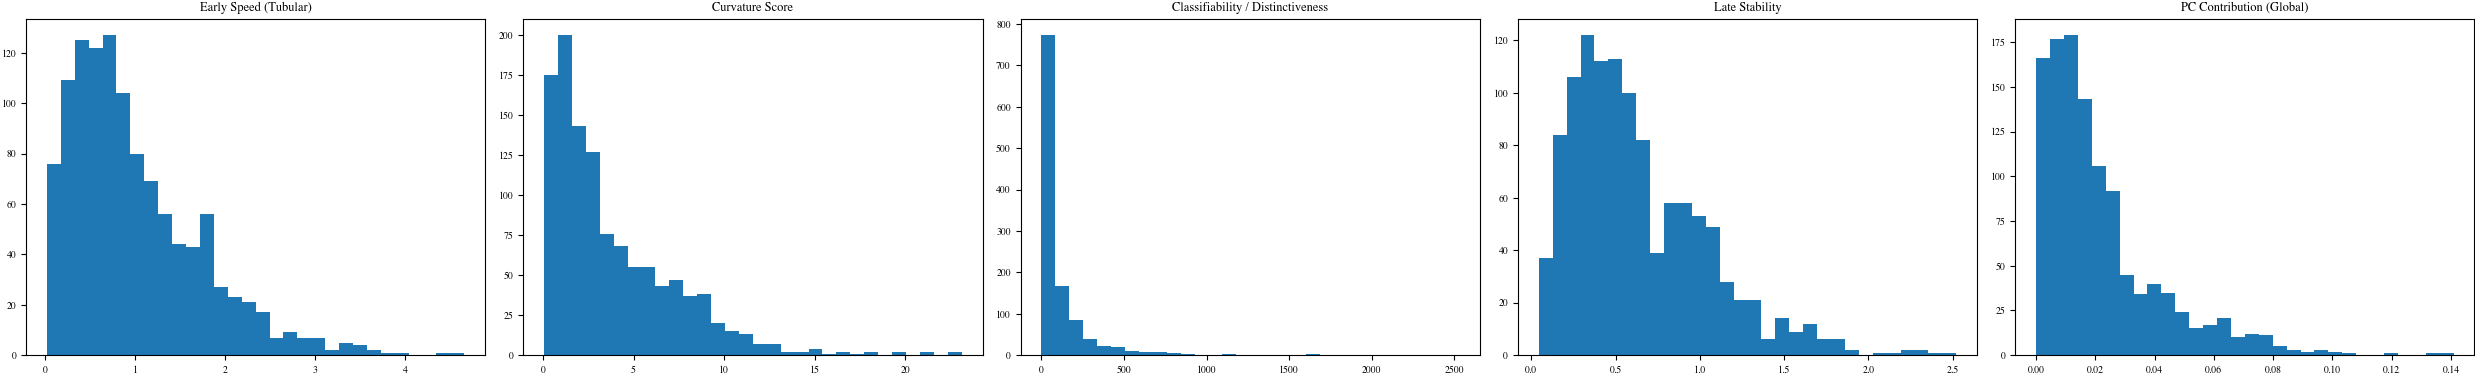

Total Neurons: 1146
Stable/Non-Tubular: 58, Tubular: 3
Linear: 58, High Curvature: 23
Non-Classifiers: 58, Classifiers: 58
Attractors: 5
Filtered tensor shape: (23, 6, 8, 135)


In [273]:
# filter neurons
# tensor4d of shape (Neurons, Stimuli, Movement Orientation, Trial length)

from scipy.ndimage import gaussian_filter1d

# --- 0. Configuration ---
# Set this to an integer (0-5) to filter based on a specific stimulus index, 
# or None for global average behavior across all stimuli.
TARGET_STIM_IDX = None
# TARGET_STIM_IDX = 0 # Example: Filter based on properties of the fist stimulus (LF-grat)

# --- 1. Compute Metrics (Per Stimulus) ---
N_neurons, N_stim, N_ori, N_time = tensor4d.shape

# A. Transients / Speed (Early vs Late)
d_tensor = np.diff(tensor4d, axis=3) # (N, S, O, T-1)
# Mean absolute change over orientations
d_tensor_mean_ori = np.mean(np.abs(d_tensor), axis=2) 
early_transients_per_stim = np.mean(d_tensor_mean_ori[:, :, :40], axis=2) # (N, S)
late_transients_per_stim = np.mean(d_tensor_mean_ori[:, :, -40:], axis=2) # (N, S)

# B. Curvature / Non-linearity (Early 40 steps)
# Average over orientations to get generic temporal profile per stim
early_traces_per_stim = np.mean(tensor4d[:, :, :, :40], axis=2)  # (N, S, 40)
# Smooth to focus on low-freq curvature
smoothed_early_per_stim = gaussian_filter1d(early_traces_per_stim, sigma=2, axis=2) # (N, S, 40)

# Vectorized Linear Fit
# Reshape to (N*S, 40) to fit all at once
flat_traces = smoothed_early_per_stim.reshape(-1, 40).T # (40, N*S)
X_time = np.vstack([np.arange(40), np.ones(40)]).T # (40, 2)
# Solve X*w = y
slopes_intercepts, _, _, _ = np.linalg.lstsq(X_time, flat_traces, rcond=None)
linear_fit_flat = (X_time @ slopes_intercepts) # (40, N*S)
# RMSE
residuals = flat_traces - linear_fit_flat
curvature_per_stim_flat = np.sqrt(np.mean(residuals**2, axis=0))
curvature_score_per_stim = curvature_per_stim_flat.reshape(N_neurons, N_stim)

# C. Stimulus Classifiability (Distinctiveness)
# Steady state mean (N, S)
steady_state_means = np.mean(np.mean(tensor4d[:, :, :, -10:], axis=3), axis=2)
# Global mean across stimuli (N, 1)
global_means = np.mean(steady_state_means, axis=1, keepdims=True)
# Distinctiveness: Distance of each stimulus from the global mean
distinctiveness_per_stim = np.abs(steady_state_means - global_means) # (N, S)
# Global Selectivity: Variance across all stimuli
global_selectivity = np.var(steady_state_means, axis=1) # (N,)


# --- 2. Select Metrics based on Configuration ---
if TARGET_STIM_IDX is not None:
    print(f"FILTERING MODE: Single Stimulus (Index {TARGET_STIM_IDX})")
    metric_speed = early_transients_per_stim[:, TARGET_STIM_IDX]
    metric_stability = late_transients_per_stim[:, TARGET_STIM_IDX]
    metric_curvature = curvature_score_per_stim[:, TARGET_STIM_IDX]
    metric_classifiability = distinctiveness_per_stim[:, TARGET_STIM_IDX]
else:
    print("FILTERING MODE: Global Average (All Stimuli)")
    metric_speed = np.mean(early_transients_per_stim, axis=1)
    metric_stability = np.mean(late_transients_per_stim, axis=1)
    metric_curvature = np.mean(curvature_score_per_stim, axis=1)
    metric_classifiability = global_selectivity # Global variance

# PC Loadings (Global only - computed once)
tensor_flat = tensor4d.transpose(1, 2, 3, 0).reshape(-1, N_neurons)
pca_global = PCA(n_components=3)
pca_global.fit(tensor_flat)
metric_pc_contrib = np.sqrt(np.sum(pca_global.components_[:1, :]**2, axis=0))


# --- 3. Visualize Distributions ---
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
axes[0].hist(metric_speed, bins=30); axes[0].set_title("Early Speed (Tubular)")
axes[1].hist(metric_curvature, bins=30); axes[1].set_title("Curvature Score")
axes[2].hist(metric_classifiability, bins=30); axes[2].set_title("Classifiability / Distinctiveness")
axes[3].hist(metric_stability, bins=30); axes[3].set_title("Late Stability")
axes[4].hist(metric_pc_contrib, bins=30); axes[4].set_title("PC Contribution (Global)")
plt.tight_layout()
plt.show()

# --- 4. Define Filters ---
# Helper to get indices by percentile
def get_idx(metric, percentile_gt=None, percentile_lt=None):
    cond = np.ones(len(metric), dtype=bool)
    if percentile_gt is not None:
        cond &= (metric > np.percentile(metric, percentile_gt))
    if percentile_lt is not None:
        cond &= (metric < np.percentile(metric, percentile_lt))
    return np.where(cond)

# Filters using the selected metrics (either global or specific stim)
# Restored: stable_orig, non_tubular (low speed)
idx_stable_orig = get_idx(metric_speed, percentile_lt=5)
idx_tubular = get_idx(metric_speed, percentile_gt=99.75)

# Curvature
idx_high_curvature = get_idx(metric_curvature, percentile_gt=98)
idx_linear = get_idx(metric_curvature, percentile_lt=5)
# Alias for low curvature if needed
idx_low_curvature = idx_linear 

# Classifiers
# Restored: non_classifiers (low classifiability/selectivity)
idx_non_classifiers = get_idx(metric_classifiability, percentile_lt=5)
idx_classifiers = get_idx(metric_classifiability, percentile_gt=95)

# Attractors: High classifiability AND high stability (low late transients)
idx_attractors = np.where(
    (metric_classifiability > np.percentile(metric_classifiability, 80)) & 
    (metric_stability < np.percentile(metric_stability, 20))
)

# PC Drivers (Always global)
idx_pc_drivers = get_idx(metric_pc_contrib, percentile_gt=95)

print(f"Total Neurons: {N_neurons}")
print(f"Stable/Non-Tubular: {len(idx_stable_orig[0])}, Tubular: {len(idx_tubular[0])}")
print(f"Linear: {len(idx_linear[0])}, High Curvature: {len(idx_high_curvature[0])}")
print(f"Non-Classifiers: {len(idx_non_classifiers[0])}, Classifiers: {len(idx_classifiers[0])}")
print(f"Attractors: {len(idx_attractors[0])}")

# --- 5. Apply Selection ---
# CHANGE THIS LINE to select the subpopulation you want to analyze
#selected_idx = idx_stable_orig
#selected_idx = idx_tubular
selected_idx = idx_high_curvature 
#selected_idx = idx_linear
#selected_idx = idx_classifiers
#selected_idx = idx_non_classifiers
#selected_idx = idx_attractors
#selected_idx = idx_pc_drivers

tensor4d = tensor4d[selected_idx]
print(f"Filtered tensor shape: {tensor4d.shape}")

In [274]:
# For Trajectories
transposed = np.transpose(tensor4d, (3, 1, 2, 0))
reshaped = transposed.reshape(-1, len(tensor4d))
print(reshaped.shape)

pca_traj = PCA(n_components=3)
pca_traj_result = pca_traj.fit_transform(reshaped)
pc1_loadings = pca_traj.components_[0]

reshaped_traj_result = pca_traj_result.reshape(tensor4d.shape[3], 6*8, -1)
trajectories = np.transpose(reshaped_traj_result, (1, 0, 2))


# For Decoding Manifold: Meaned traces
first_n_points = tensor4d.shape[3]

meaned = np.mean(transposed[:first_n_points], axis=0)
reshaped = meaned.reshape(-1, len(tensor4d))

pca_decoding = PCA(n_components=3)
pca_decoding_result = pca_decoding.fit_transform(reshaped)
print(np.sum(pca_decoding.explained_variance_ratio_))

reshaped_decoding_result = pca_decoding_result.reshape(6*8, -1)

(6480, 23)
0.9612386


/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/pyth

## Decoding Manifold

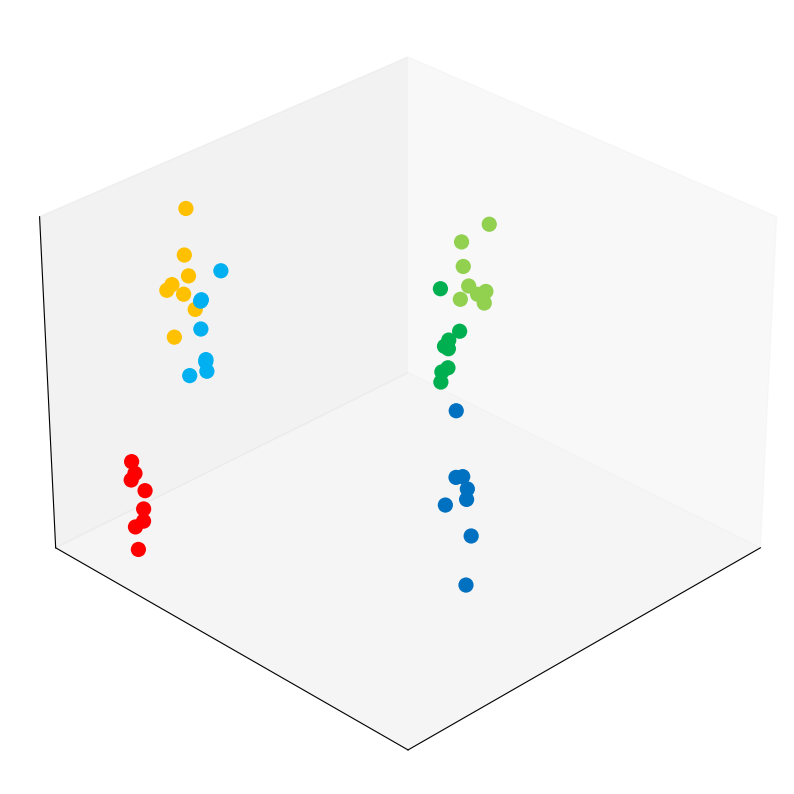

In [275]:
stimulus_colors = [
    '#0070C0', '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000', 
    '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000'
]
labels = [
    'LF-grat', 'HF-grat', '-1dot', '-3dot', '+1dot', '+3dot',
    'HF-grat-2', '-1dot-2', '-3dot-2', '+1dot-2', '+3dot-2'
]

n_per_label = 8
clrs = []
legend_labels = []
for i in range(6):  # Adjusted to 11 to match your labels list length
    if i < len(stimulus_colors):
        clrs.extend([stimulus_colors[i]] * n_per_label)
        legend_labels.extend([labels[i]] * n_per_label)
clrs = np.array(clrs)
legend_labels = np.array(legend_labels)

# Create Matplotlib Figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each group
for i, label in enumerate(labels):
    mask = (legend_labels == label)
    if np.any(mask):
        # Matplotlib scatter
        ax.scatter(
            reshaped_decoding_result[mask, 0],
            reshaped_decoding_result[mask, 1],
            reshaped_decoding_result[mask, 2],
            color=stimulus_colors[i],
            s=120,  # Size (Matplotlib uses points^2, so 100 is roughly similar to Plotly 10)
            label=label,
            alpha=1.0,
            edgecolors='none' # Removes outlines for cleaner look
        )

# Remove axes details to match your "clean" Plotly look
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# Viewpoint (optional: adjust elevation and azimuth to match your preference)
ax.view_init(elev=30, azim=45)

# Save as true Vector PDF
plt.savefig(f'../fig/decoding_manifolds/{PREFIX}_decoding.pdf', format='pdf', bbox_inches='tight', dpi=300)

## Plot Trajectories and Crossings

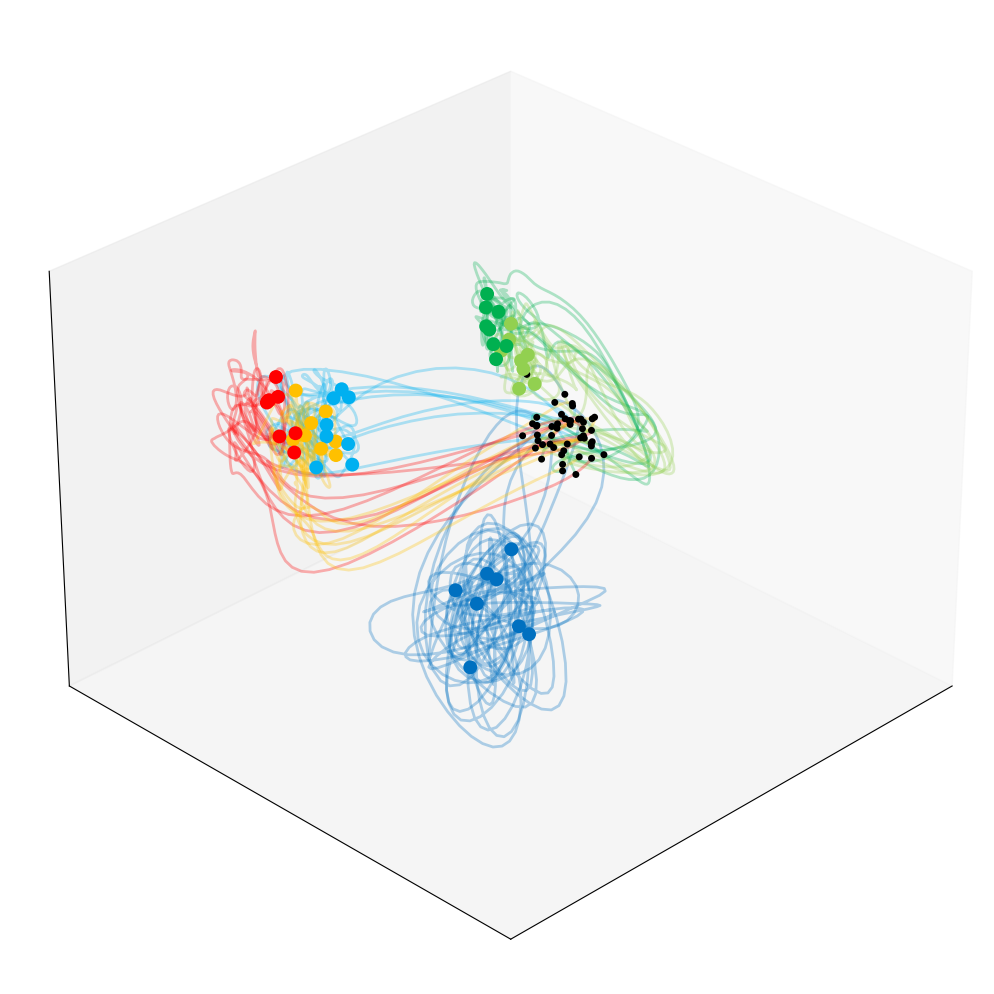

Saved to ../fig/decoding_trajectories/crossings_Retina.pdf


In [276]:
def plot_trajectories_matplotlib(trajectories, prefix="prefix", filename="filename"):
    """
    Plot 3D trajectories using Matplotlib (Vector/PDF safe).
    """
    # 1. Setup Colors and Names (Same as original)
    stimulus_colors = [
        '#0070C0', '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000', 
        '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000'
    ]

    # 2. Initialize Figure
    fig = plt.figure(figsize=(12, 10)) # High res figure size
    ax = fig.add_subplot(111, projection='3d')
    
    # 3. Plot Loop
    for i, traj in enumerate(trajectories):
        # Apply the same z-scaling as your Plotly code
        x, y, z = traj[:, 0], traj[:, 1], traj[:, 2] * 0.5
        
        # Determine grouping
        stimulus_idx = i // 8
        stimulus_color = stimulus_colors[stimulus_idx % 11]
        
        # A. Plot the Trajectory Line
        ax.plot(
            x, y, z, 
            color=stimulus_color, 
            linewidth=2,      # Approx equivalent to Plotly width=5
            alpha=0.3         # Opacity
        )
        
        # B. Start Point (Black)
        ax.scatter(
            x[0], y[0], z[0], 
            color='black', 
            s=25,             # Size (points^2). 25 is approx size 5 in Plotly
            depthshade=False, # Keep color solid black regardless of depth
            edgecolors='none'
        )
        
        # C. End Point (Stimulus Colored)
        ax.scatter(
            x[-1], y[-1], z[-1], 
            color=stimulus_color, 
            s=100,            # Size (points^2). 100 is approx size 10 in Plotly
            depthshade=False,
            edgecolors='none'
        )

    # 4. Styling (Mimicking "plotly_white" and your specific axis settings)
    
    # Remove the gray background panes
    #ax.xaxis.pane.fill = False
    #ax.yaxis.pane.fill = False
    #ax.zaxis.pane.fill = False
    
    # Remove grids
    ax.grid(False)
    
    # Remove tick labels (but keep axis lines visible)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    
    # Make the axis lines (spines) thicker and black
    # Note: Matplotlib 3D axis styling is tricky; we style the pane edges
    # or set the axis line color to transparency if you strictly want NO lines.
    # However, based on your request for "linewidth=2, linecolor='black'", 
    # we retain the structure:
    ax.xaxis.line.set_color('black')
    ax.yaxis.line.set_color('black')
    ax.zaxis.line.set_color('black')
    
    # Set Initial View (Adjust as needed to match your preferred angle)
    ax.view_init(elev=30, azim=45)
    
    # Optional: Auto-scale aspect ratio to be cubic (like Plotly often does)
    # ax.set_box_aspect([1,1,1]) 

    # 5. Save
    output_path = f'../fig/decoding_trajectories/crossings_{prefix}.pdf'
    plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig) # Close to free memory
    print(f"Saved to {output_path}")

# Usage:
plot_trajectories_matplotlib(trajectories, prefix=PREFIX)

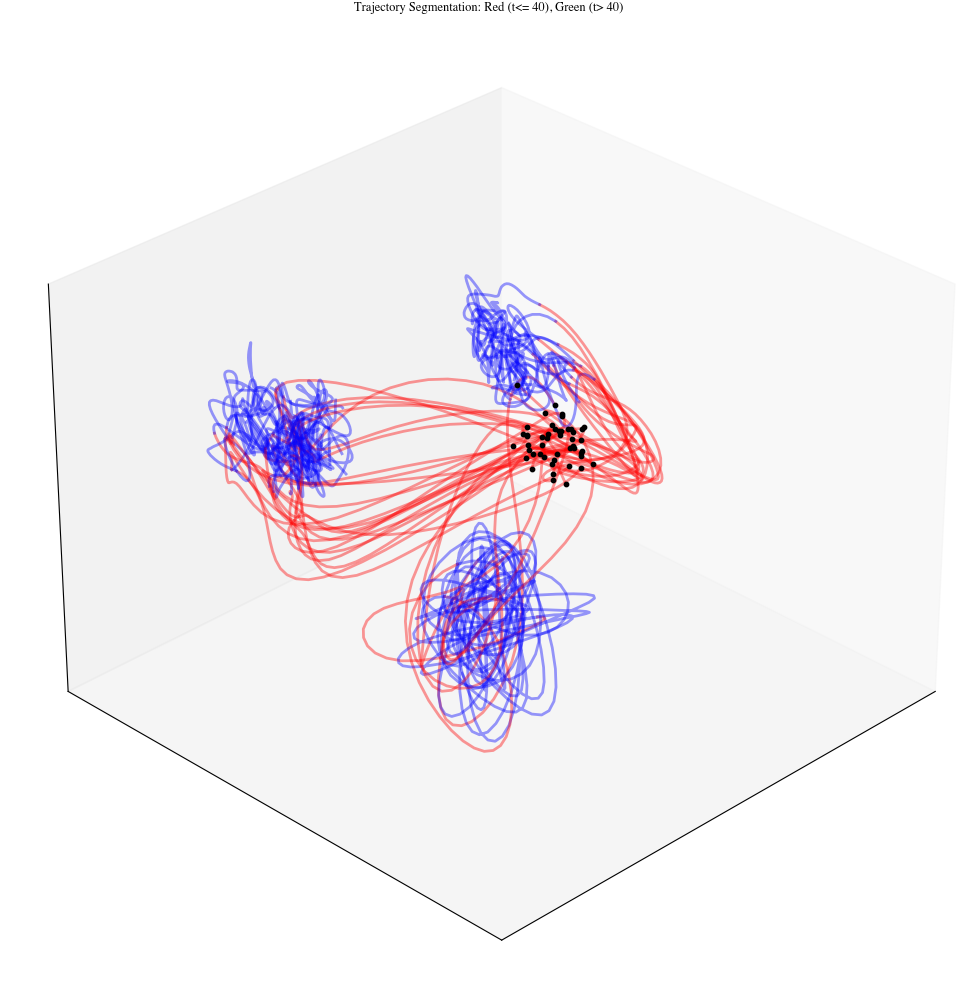

In [277]:
# Validation Plot: Time Segmentation
# Plots all trajectories with the first 40 steps in RED and the rest in GREEN
# This helps visually verify if t=40 captures the curved initial dynamics.

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Cutoff time step
CUTOFF = 40

for i, traj in enumerate(trajectories):
    # Trajectory shape: (Time_steps, 3)
    x, y, z = traj[:, 0], traj[:, 1], traj[:, 2]
    
    # Apply same z-scaling as before for consistency
    z = z * 0.5
    
    # Early segment (Red) - Curvature / Transient
    # We include CUTOFF in both to ensure the line is continuous
    ax.plot(
        x[:CUTOFF+1], y[:CUTOFF+1], z[:CUTOFF+1], 
        color='red', alpha=0.4, linewidth=2
    )
    
    # Late segment (Green) - Stability / Attractor
    ax.plot(
        x[CUTOFF:], y[CUTOFF:], z[CUTOFF:], 
        color='blue', alpha=0.4, linewidth=2
    )
    
    # Start point
    ax.scatter(x[0], y[0], z[0], color='black', s=10, depthshade=False)

# Styling and View
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.grid(False)
ax.xaxis.line.set_color('black')
ax.yaxis.line.set_color('black')
ax.zaxis.line.set_color('black')

ax.view_init(elev=30, azim=45)
ax.set_title(f"Trajectory Segmentation: Red (t<= {CUTOFF}), Green (t> {CUTOFF})")

plt.show()